# Interactive Plotting

##### Version 0.1

***

Adapted from slides by Bryan Scott (Session 17, Texas A&M, 2 March 2023)

By Adam A Miller   
(Northwestern/CIERA/SkAI)  
24 August 2026

There is fundamental tension at every DSFP session – principles vs. tools.

The pedagogical standard is straightforward: teach the principles of data science so the practitioners can use whatever tools they like. 

(Tools change, principles do not...)

And yet...

If you do not have/know about *any* tools, then it is exceptionally hard to put any principle into practice. 

This is especially true for visualization, because the tools enable your exploration and communication. 

And yet, and yet...

AI agents can quickly produce a (preliminary) version of whatever visualization you want, without a particularly detailed knowledge of the tools used to render that visualization. 

Thus, this session has a minimal focus on *tools* (just this lecture and one more on 3D rendering later this week). 

This lecture provides a (very) brief intro to interactive-plotting in python. Hopefully some of you find this useful for the hack day.

Static figures answer questions you already knew to ask. 

Interactive figures let you find the question.

(i.e., static figs are a poor way to *explore*.)

Rubin will provide $>1$ billion rows and hundreds of columns, what then should we plot against each other on a 2D screen?

Interactivity enables exploration in ways that static figures cannot:

$~~~$Zoom and pan

$~~~$Hover – identity for individual points, without a legend of 400 entries

$~~~$Linked selection – brush a region in one panel, watch the others respond

Before dunking on `matplotlib`, note that (some) interactive functionality is already built in (and easily accessible with jupyter magic). 

| magic | what you get |
|---|---|
| `%matplotlib inline` | static PNG (the default) |
| `%matplotlib widget` | pan, zoom, cursor readout, in JupyterLab |
| `%matplotlib ipympl` | the same thing, named after the package |
| `%matplotlib qt` | a separate desktop window |

`ipympl` is my favorite and the reason many of your DSFP notebooks break right after you `git pull upstream`. 

If you do not have `ipympl`, you should install it with `conda install -c conda-forge ipympl` 

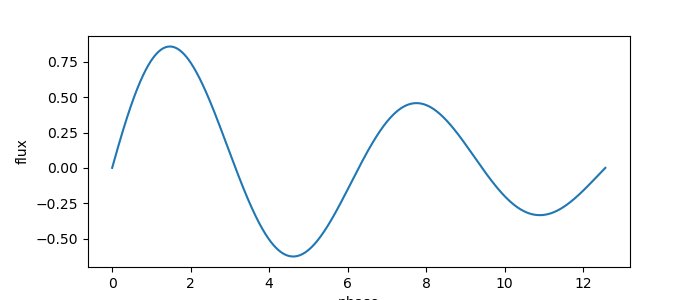

In [1]:
# requires: pip install ipympl
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 4*np.pi, 2000)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, np.sin(x) * np.exp(-x/10))
ax.set_xlabel('phase'); ax.set_ylabel('flux')
plt.show()

Important caveat: under `ipympl` a figure is a *widget*, and it renders only when something displays it. Functions that draw but return `None` – like `healpy.mollview` from earlier today – produce no output at all in `ipympl`.

For parameter exploration, `ipywidgets` is the natural partner.

In [2]:
# requires: pip install ipywidgets
# from ipywidgets import interact
#
# @interact(period=(0.1, 5.0, 0.1), damping=(0.0, 0.5, 0.01))
# def plot_curve(period=1.0, damping=0.1):
#     fig, ax = plt.subplots(figsize=(7, 3))
#     ax.plot(x, np.sin(2*np.pi*x/period) * np.exp(-damping*x))
#     plt.show()

Is `matplotlib` all you need?

$~~~$It redraws in Python, so it gets slow well before a million points

$~~~$There is no linked brushing between panels

$~~~$You cannot email someone an `ipympl` figure

Sharing interactive figures can be important if you work in large collaborations. If the interactivity is limited to your machine then it is difficult to communicate. 

There are many tools we could teach your about for interactivity...

<img style="display: block; margin-left: auto; margin-right: auto" src="images/tools_fig01_landscape.png" width="850" alt="Scatter plot placing matplotlib, seaborn, ipympl, altair, plotly, bokeh, Dash and d3.js by browser interactivity and how much code you must write" align="middle">

Two primary questions: (1) how much code must you write, and (2) how much interactivity do you want in the browser?

$~~~$**seaborn** – statistical grammar over matplotlib. Still static, still a `matplotlib` figure underneath.

$~~~$**bokeh** – web-native, strong at linked brushing and server-backed apps.

$~~~$**plotly** – web-native, the broadest chart vocabulary, easiest to share.

$~~~$**d3.js** – not a plotting library. A toolkit for binding data to a document.

d3 is the "standard" if you are truly publishing interactive data (python-based tools are trying their best to "copy" d3).

d3 is JavaScript.

It does not "give" charts, only the machinery to map data onto shapes and let the browser draw them.

Everything is possible; nothing is quick.

Let's proceed with a rapid overview of `plotly`. 

It is the best choice to illustrate interactivity: it is a Python library that emits a self-contained interactive figure, and hover, zoom and legend-toggling are all included.

There are two APIs:

$~~~$**`plotly.express`** – one line per figure. Best for beginners.

$~~~$**`plotly.graph_objects`** – build the figure explicitly (after getting some experience with express).

In [3]:
import plotly.io as pio
pio.renderers.default = 'iframe'

In [4]:
import plotly.express as px

df = px.data.iris()
fig = px.scatter(df, x='sepal_width', y='sepal_length',
                 color='species', hover_data=['petal_width'])
fig.show()

That is a complete interactive figure. Hover a point and you get its identity; drag to zoom; click a legend entry to hide a class.

One line of code in `plotly` and an incredible amount of effort in `matplotlib`.

What is actually happening? 

Underneath, express just built a `graph_objects.Figure`.

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/tools_fig02_figure_anatomy.png" width="850" alt="Schematic showing a plotly Figure splitting into fig.data, a tuple of traces, and fig.layout, everything that is not data" align="middle">

`fig.data` is a tuple of *traces*. One trace is one set of marks: a scatter, a surface, a histogram.

`fig.layout` is everything else: axes, title, legend, annotations, menus.

In [5]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Scatter(x=['a', 'b', 'c'], y=[1, 3, 2], mode='lines')],
    layout=go.Layout(title='sample figure',
                     xaxis={'title': {'text': 'x'}},
                     yaxis={'title': {'text': 'y'}})
)
print(type(fig.data), len(fig.data))
print(type(fig.data[0]))

<class 'tuple'> 1
<class 'plotly.graph_objs._scatter.Scatter'>


Print the object and you get everything back as a dict.

`plotly` figures are data, not code! 

It serialises to JSON, which is what makes it possible to hand the whole thing to a browser.

In [6]:
print(fig)

Figure({
    'data': [{'mode': 'lines', 'type': 'scatter', 'x': ['a', 'b', 'c'], 'y': [1, 3, 2]}],
    'layout': {'template': '...',
               'title': {'text': 'sample figure'},
               'xaxis': {'title': {'text': 'x'}},
               'yaxis': {'title': {'text': 'y'}}}
})


Because it is just a structure, you can edit it after the fact rather than rebuilding it.

In [7]:
fig.update_traces(line_color='#C1443C', line_width=3)
fig.update_layout(template='simple_white', width=650, height=350)
fig.show()

### Positioning

Multiple panels come from `make_subplots`, and each trace is told which cell it belongs to.

In [8]:
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('flux', 'residual'))
fig.add_trace(go.Scatter(y=[1, 3, 2], name='flux'), row=1, col=1)
fig.add_trace(go.Scatter(y=[0.1, -0.2, 0.05], name='residual'), row=1, col=2)
fig.update_layout(height=320, showlegend=False)
fig.show()

In the raw layout this is expressed with `domain` (where an axis sits on the page, in figure fractions) and `anchor` (which other axis it is pinned to). `make_subplots` writes those for you, and it is worth printing `fig.layout` once to see what it wrote.

The menus and buttons allow `plotly` to be an interface for exploration.

You can attach controls that modify the figure, without a new rendering (i.e.,  the browser does the work).

Three methods allow the control of the Figure anatomy:

$~~~$`restyle` – modify **data** or trace attributes

$~~~$`relayout` – modify **layout** attributes

$~~~$`update` – both at once

In [9]:
import numpy as np

z = np.random.default_rng(42).normal(size=(30, 30)).cumsum(axis=0).cumsum(axis=1)
fig = go.Figure(data=[go.Surface(z=z, colorscale='Viridis')])

fig.update_layout(
    updatemenus=[dict(
        type='buttons',
        direction='left',
        buttons=[
            dict(args=['type', 'surface'], label='3D Surface', method='restyle'),
            dict(args=['type', 'heatmap'], label='Heatmap', method='restyle'),
        ],
        showactive=True,
        x=0.11, xanchor='left', y=1.1, yanchor='top',
    )],
    height=450, margin=dict(t=60),
)
fig.show()

One trace, two representations, and the reader chooses.

Note that `args=['type', 'surface']` is just an edit to the figure's data specification. `method='restyle'` says apply it to `fig.data`.

Sliders work the same way, which is how you animate a light curve or step through a cadence.

### Getting it out of the notebook

A plotly figure is HTML plus JSON, so it can easily be exported.

In [10]:
# fig.write_html('figure.html')                 # standalone, opens anywhere
# fig.write_html('fig.html', include_plotlyjs='cdn')   # ~3 MB smaller

`write_html` produces a file you can email to a collaborator, attach to an issue, or drop on a webpage.

`ipympl` can't do that.

If a figure will not render in JupyterLab, it is almost always the renderer rather than your code. `import plotly.io as pio; print(pio.renderers.default)` and try setting it to `'notebook'`, `'iframe'`, or `'browser'`.

How do you choose which tool? (Here is an incomplete guide...)

| if you are... | use |
|---|---|
| making a figure for a paper | matplotlib (+ seaborn) |
| inspecting an image or light curve | matplotlib + `ipympl` |
| exploring a table you do not know yet | plotly express |
| building a figure others will click through | plotly graph_objects |
| linking many panels over a large dataset | bokeh |
| shipping a tool, not a figure | Dash |
| the visualization *is* the paper | d3.js |

A note in closing – a figure that requires the reader to hover, zoom and toggle before it says anything means you are asking the reader to *do the work*.

Interaction is super useful for exploration, but should not be a crutch when making specific scientific claims. 

### Further reading

* [Plotly Python documentation](https://plotly.com/python/)
* [Plotly figure reference](https://plotly.com/python/reference/)
* [ipympl](https://matplotlib.org/ipympl/)
* [Bokeh](https://docs.bokeh.org/) and [Dash](https://dash.plotly.com/)
* [Observable / d3.js](https://d3js.org/)

# Appendix: Figure Generation

The two schematic figures are built by the code below, which writes PNGs into `images/`.

### A.1 Figure code

In [11]:
"""Figures for the visualization-tools slides.

Follows the lecture convention: matplotlib only, PNGs written to images/,
no titles on the figures -- axis labels and in-panel annotation only.
"""
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "savefig.bbox": "tight",
    "font.size": 11, "axes.labelsize": 11,
})

IMDIR = "images"


def savefig(fig, name):
    os.makedirs(IMDIR, exist_ok=True)
    path = f"{IMDIR}/{name}.png"
    fig.savefig(path)
    plt.close(fig)
    print(f"wrote {path}")
    return path


# ----------------------------------------------------------------------
def fig_landscape():
    """Where the common Python plotting libraries sit."""
    tools = [
        # name,             x = interactivity, y = control you must exert
        ("matplotlib",      0.12, 0.55, "#1f4e79"),
        ("seaborn",         0.10, 0.22, "#4a7ba7"),
        ("ipympl",          0.42, 0.52, "#1f4e79"),
        ("plotly express",  0.72, 0.16, "#C1443C"),
        ("plotly graph_objects", 0.63, 0.55, "#C1443C"),
        ("bokeh",           0.80, 0.60, "#2e8b57"),
        ("altair",          0.58, 0.32, "#7b5aa6"),
        ("Dash",            0.93, 0.74, "#C1443C"),
        ("d3.js",           0.96, 0.96, "#d98218"),
    ]
    fig, ax = plt.subplots(figsize=(9.5, 5.6))
    for name, x, y, c in tools:
        ax.scatter([x], [y], s=260, color=c, zorder=3, edgecolor="w", lw=1.2)
        ax.annotate(name, (x, y), xytext=(0, 14), textcoords="offset points",
                    ha="center", fontsize=10, color=c, weight="bold")

    ax.set_xlim(0, 1.03)
    ax.set_ylim(0, 1.12)
    ax.set_xlabel("interactivity in the browser  " + r"$\longrightarrow$")
    ax.set_ylabel("code you must write yourself  " + r"$\longrightarrow$")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(color="0.9", lw=0.6)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

    ax.annotate("publication figures", (0.05, 0.04), fontsize=9,
                color="0.45", style="italic")
    ax.annotate("exploration and sharing", (0.60, 0.04), fontsize=9,
                color="0.45", style="italic")
    return savefig(fig, "tools_fig01_landscape")


# ----------------------------------------------------------------------
def fig_figure_anatomy():
    """A plotly Figure is exactly two things: data and layout."""
    fig, ax = plt.subplots(figsize=(10, 5.2))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5.6)
    ax.axis("off")

    def box(x, y, w, h, label, sub, fc, ec, fs=11):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                                    facecolor=fc, edgecolor=ec, lw=1.4))
        ax.text(x + w/2, y + h - 0.32, label, ha="center", va="top",
                fontsize=fs, weight="bold", color=ec)
        if sub:
            ax.text(x + w/2, y + h - 0.72, sub, ha="center", va="top",
                    fontsize=9, color="0.3")

    box(0.3, 3.9, 9.4, 1.4, "go.Figure", "the whole plot, and the only thing "
        "you ever hand to .show()", "#eef3f8", "#1f4e79", 13)

    box(0.6, 1.15, 4.3, 2.35, "fig.data", "a tuple of traces", "#fdeeec", "#C1443C")
    for nm, dy in [("go.Scatter", 0.0), ("go.Histogram2d", 0.45),
                   ("go.Surface", 0.90)]:
        ax.text(2.75, 2.28 - dy, nm, ha="center", fontsize=9.5,
                family="monospace", color="0.25")

    box(5.1, 1.15, 4.3, 2.35, "fig.layout", "everything that is not data",
        "#eef7ee", "#2e8b57")
    for nm, dy in [("xaxis, yaxis", 0.0), ("title, legend", 0.45),
                   ("updatemenus", 0.90)]:
        ax.text(7.25, 2.28 - dy, nm, ha="center", fontsize=9.5,
                family="monospace", color="0.25")

    for x0 in (2.75, 7.25):
        ax.add_patch(FancyArrowPatch((x0, 3.5), (x0, 3.88),
                                     arrowstyle="-|>", mutation_scale=14,
                                     color="0.5", lw=1.2))

    ax.text(2.75, 0.72, "one trace = one set of\nmarks on the page",
            ha="center", fontsize=9, color="0.45", style="italic")
    ax.text(7.25, 0.72, "restyle edits data,\nrelayout edits layout",
            ha="center", fontsize=9, color="0.45", style="italic")
    return savefig(fig, "tools_fig02_figure_anatomy")

### A.2 Build both figures

In [12]:
fig_landscape()
fig_figure_anatomy()

wrote images/tools_fig01_landscape.png
wrote images/tools_fig02_figure_anatomy.png


'images/tools_fig02_figure_anatomy.png'